<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # upload FruitinAmazon.zip

with zipfile.ZipFile('FruitinAmazon.zip', 'r') as z:
    z.extractall('.')

base = 'FruitinAmazon'
if 'FruitinAmazon' in os.listdir(base):
    base = 'FruitinAmazon/FruitinAmazon'

train_dir = os.path.join(base, 'train')
test_dir  = os.path.join(base, 'test')

print("Train classes:", sorted(os.listdir(train_dir)))
print("Test classes :", sorted(os.listdir(test_dir)))

Saving FruitinAmazon.zip to FruitinAmazon.zip
Train classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [2]:
import os

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [3]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
                os.remove(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [4]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


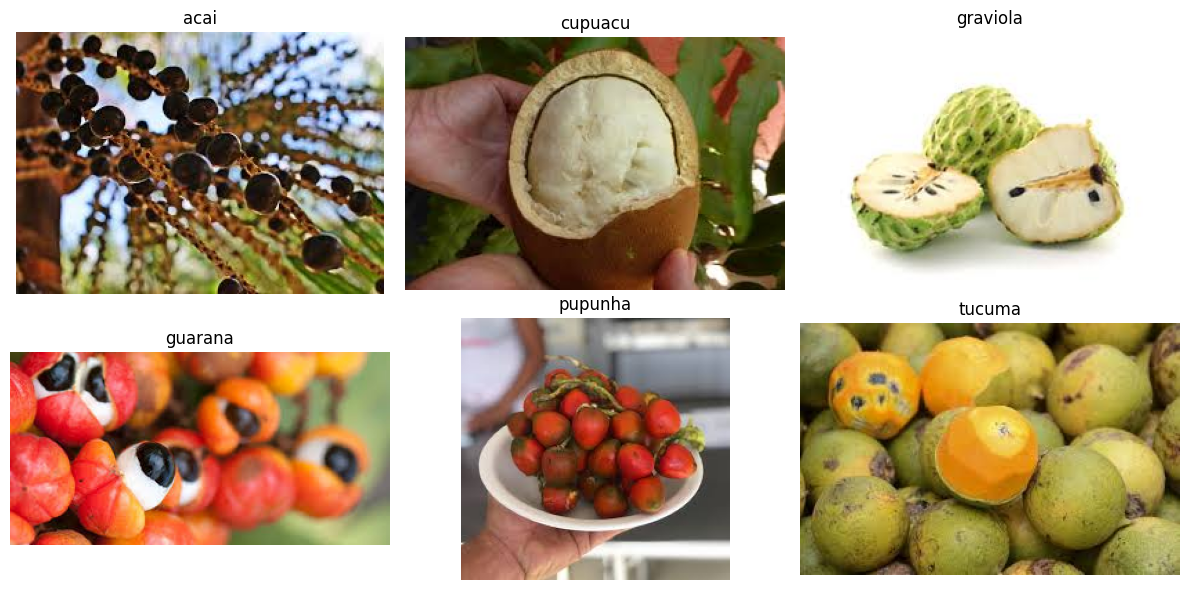

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_imgs = len(selected_images)
cols = (num_imgs + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_imgs:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf
import numpy as np

img_height = 128
img_width  = 128
batch_size = 4

# Use subset="both" to get train+val in one call
train_ds_raw, val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

# ✅ Save class names BEFORE .map()
class_names  = train_ds_raw.class_names
num_classes  = len(class_names)

print("Classes    :", class_names)
print("Num classes:", num_classes)

# Check batch shape
for images, labels in train_ds_raw.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Classes    : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6
Images shape: (4, 128, 128, 3)
Labels shape: (4,)


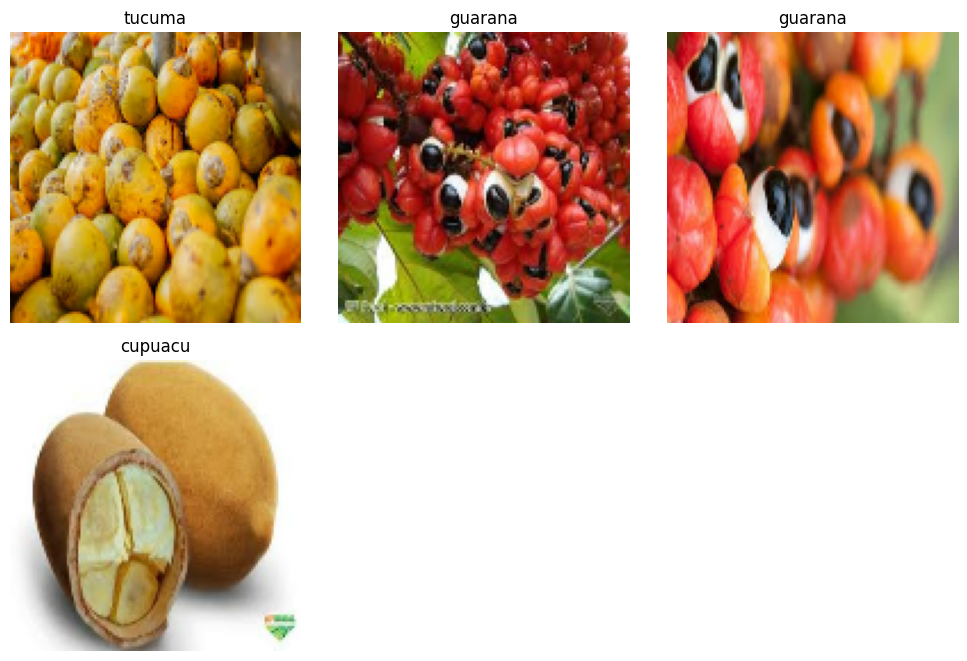

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds_raw.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras import layers

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

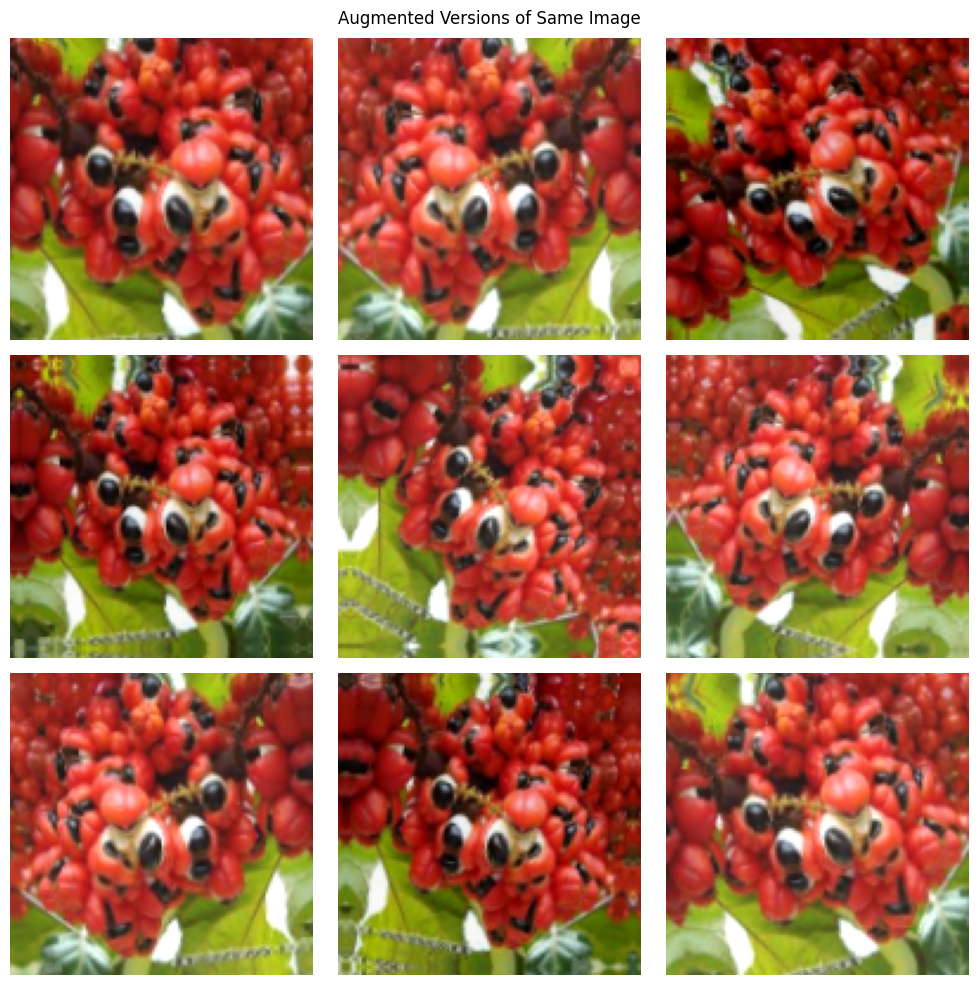

In [9]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds_raw.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Augmented Versions of Same Image")
plt.tight_layout()
plt.show()

In [14]:
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_class_names = test_ds_raw.class_names
print("Test classes:", test_class_names)

Found 30 files belonging to 6 classes.
Test classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation,
    Rescaling, RandomFlip, RandomRotation, RandomZoom
)

model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Augmentation (runs on GPU during fit, skipped during evaluate/predict)
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Rescaling
    Rescaling(1./255),

    # Conv Block 1
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten + FC
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,409,798 (32.08 MB)

 Trainable params: 8,409,350 (32.08 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ✅ Cache and prefetch for speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds_fast = train_ds_raw.cache().shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_ds_fast   = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

checkpoint_cb = ModelCheckpoint(
    'best_model_w6.h5',
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=20,              # stops early instead of running all 250
    restore_best_weights=True,
    verbose=1
)

# ✅ Reduces LR when stuck — converges faster
reducelr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds_fast,
    epochs=250,
    validation_data=val_ds_fast,
    callbacks=[checkpoint_cb, earlystop_cb, reducelr_cb]
)

Epoch 1/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.2312 - loss: 2.2714
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model_w6.h5



Epoch 1: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 382ms/step - accuracy: 0.2917 - loss: 2.1009 - val_accuracy: 0.3333 - val_loss: 1.7114 - learning_rate: 0.0010
Epoch 2/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3493 - loss: 1.6122
Epoch 2: val_accuracy did not improve from 0.33333
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 294ms/step - accuracy: 0.4306 - loss: 1.5003 - val_accuracy: 0.2778 - val_loss: 1.6751 - learning_rate: 0.0010
Epoch 3/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5460 - loss: 1.3007
Epoch 3: val_accuracy did not improve from 0.33333
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 298ms/step - accuracy: 0.5417 - loss: 1.2962 - val_accuracy: 0.2222 - val_loss: 1.8235 - learning_rate: 0.0010
Epoch 4/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.5583 - loss: 1.3041
Epoch 4: val_accuracy did not improve from 0.33333
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.5694 - loss: 1.2498 - val_accuracy: 0.3333 - val_loss: 


Epoch 6: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 323ms/step - accuracy: 0.6111 - loss: 0.9761 - val_accuracy: 0.3889 - val_loss: 2.2248 - learning_rate: 0.0010
Epoch 7/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.6799 - loss: 0.7714
Epoch 7: val_accuracy did not improve from 0.38889

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 330ms/step - accuracy: 0.6806 - loss: 0.8196 - val_accuracy: 0.2778 - val_loss: 2.2798 - learning_rate: 0.0010
Epoch 8/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6348 - loss: 0.8312
Epoch 8: val_accuracy did not improve from 0.38889
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 298ms/step - accuracy: 0.6111 - loss: 0.8732 - val_accuracy: 0.2222 - val_loss: 2.3070 - learning_rate: 5.0000e-04
Epoch 9/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7377 - loss: 0.7882
Epoch 9: val_accuracy did not improve from 0.38889
18/18 ━━━━━━━━━━━━━━━━━━━━ 10


Epoch 26: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 309ms/step - accuracy: 0.9583 - loss: 0.3023 - val_accuracy: 0.4444 - val_loss: 1.7607 - learning_rate: 6.2500e-05
Epoch 27/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8777 - loss: 0.4036
Epoch 27: val_accuracy did not improve from 0.44444

Epoch 27: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 327ms/step - accuracy: 0.9028 - loss: 0.3840 - val_accuracy: 0.4444 - val_loss: 1.7375 - learning_rate: 6.2500e-05
Epoch 28/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9653 - loss: 0.2376
Epoch 28: val_accuracy did not improve from 0.44444
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.9861 - loss: 0.2535 - val_accuracy: 0.4444 - val_loss: 1.6701 - learning_rate: 3.1250e-05
Epoch 29/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8697 - loss: 0.4062
Epoch 29: val_accuracy improved from 0.44444 to 0.50000, saving mo


Epoch 29: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step - accuracy: 0.9306 - loss: 0.3134 - val_accuracy: 0.5000 - val_loss: 1.6014 - learning_rate: 3.1250e-05
Epoch 30/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9883 - loss: 0.2326
Epoch 30: val_accuracy improved from 0.50000 to 0.55556, saving model to best_model_w6.h5



Epoch 30: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.9722 - loss: 0.2944 - val_accuracy: 0.5556 - val_loss: 1.5530 - learning_rate: 3.1250e-05
Epoch 31/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9267 - loss: 0.2801
Epoch 31: val_accuracy improved from 0.55556 to 0.61111, saving model to best_model_w6.h5



Epoch 31: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 305ms/step - accuracy: 0.9444 - loss: 0.3045 - val_accuracy: 0.6111 - val_loss: 1.5297 - learning_rate: 3.1250e-05
Epoch 32/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9413 - loss: 0.3145
Epoch 32: val_accuracy did not improve from 0.61111
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 359ms/step - accuracy: 0.9444 - loss: 0.2865 - val_accuracy: 0.6111 - val_loss: 1.5136 - learning_rate: 3.1250e-05
Epoch 33/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9690 - loss: 0.3304
Epoch 33: val_accuracy did not improve from 0.61111
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - accuracy: 0.9583 - loss: 0.2973 - val_accuracy: 0.6111 - val_loss: 1.5105 - learning_rate: 3.1250e-05
Epoch 34/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8789 - loss: 0.4102
Epoch 34: val_accuracy improved from 0.61111 to 0.72222, saving model to best_model_w6.h5



Epoch 34: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 374ms/step - accuracy: 0.9028 - loss: 0.3951 - val_accuracy: 0.7222 - val_loss: 1.5325 - learning_rate: 3.1250e-05
Epoch 35/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9960 - loss: 0.2874
Epoch 35: val_accuracy did not improve from 0.72222
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - accuracy: 0.9722 - loss: 0.2982 - val_accuracy: 0.7222 - val_loss: 1.5175 - learning_rate: 3.1250e-05
Epoch 36/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9922 - loss: 0.2490
Epoch 36: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model_w6.h5



Epoch 36: finished saving model to best_model_w6.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step - accuracy: 0.9722 - loss: 0.2942 - val_accuracy: 0.7778 - val_loss: 1.5070 - learning_rate: 3.1250e-05
Epoch 37/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9632 - loss: 0.2253
Epoch 37: val_accuracy did not improve from 0.77778
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - accuracy: 0.9583 - loss: 0.2664 - val_accuracy: 0.7778 - val_loss: 1.5019 - learning_rate: 3.1250e-05
Epoch 38/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9569 - loss: 0.2197
Epoch 38: val_accuracy did not improve from 0.77778
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.9306 - loss: 0.2852 - val_accuracy: 0.7778 - val_loss: 1.5124 - learning_rate: 3.1250e-05
Epoch 39/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9261 - loss: 0.2954
Epoch 39: val_accuracy did not improve from 0.77778
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.9583 - loss: 0.2990 - val_accuracy: 

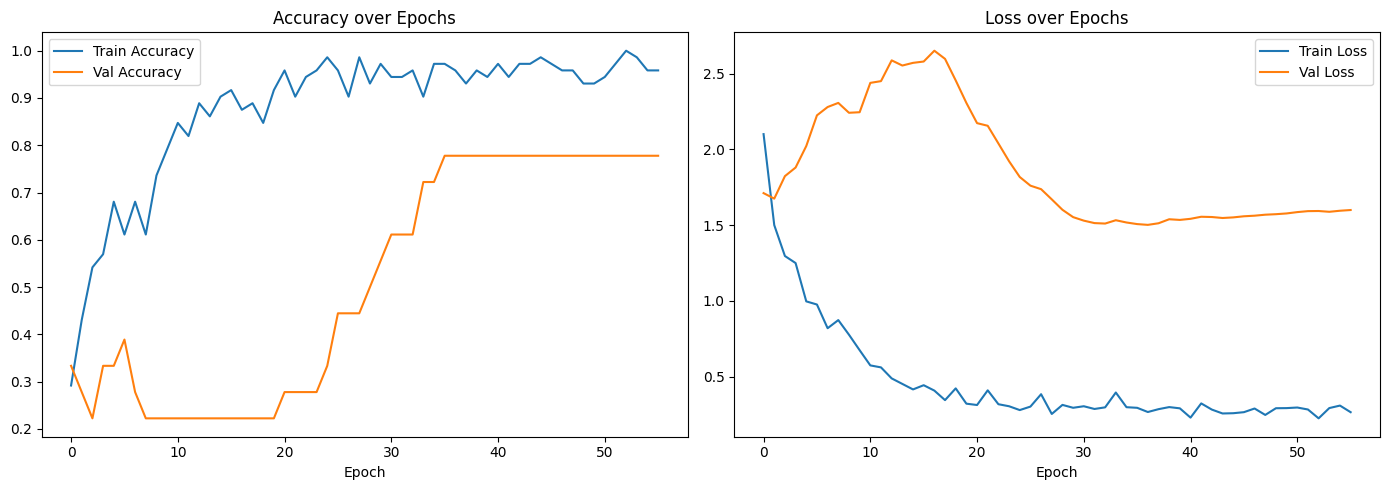

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

loaded_model = load_model('best_model_w6.h5')

y_true, y_pred = [], []

for images, labels in val_ds_raw:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

unique_labels      = sorted(np.unique(y_true))
actual_class_names = [class_names[i] for i in unique_labels]

print(classification_report(
    y_true, y_pred,
    labels=unique_labels,
    target_names=actual_class_names,
    zero_division=0
))

              precision    recall  f1-score   support

        acai       0.75      1.00      0.86         3
     cupuacu       0.80      1.00      0.89         4
    graviola       1.00      1.00      1.00         1
     guarana       0.50      1.00      0.67         1
     pupunha       0.80      1.00      0.89         4
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.78        18
   macro avg       0.81      0.87      0.77        18
weighted avg       0.84      0.78      0.72        18



In [22]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# VGG16 needs 224x224 — reload datasets at correct size
IMG_SIZE = 224

train_vgg_raw, val_vgg_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
)

# ✅ class names before map
vgg_class_names = train_vgg_raw.class_names
vgg_num_classes = len(vgg_class_names)

# Rescale to [0,1]
rescale = tf.keras.layers.Rescaling(1./255)
train_vgg = train_vgg_raw.map(lambda x, y: (rescale(x), y))
val_vgg   = val_vgg_raw.map(lambda x, y: (rescale(x), y))

print("VGG classes:", vgg_class_names)
print("Num classes:", vgg_num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
VGG classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6


In [23]:
# Load base model — no top layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(vgg_num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=x)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
# Change from 224 to 128 — VGG16 still works, much faster
IMG_SIZE = 128

train_vgg_raw, val_vgg_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=batch_size,
)

vgg_class_names = train_vgg_raw.class_names
vgg_num_classes = len(vgg_class_names)

rescale = tf.keras.layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_vgg = train_vgg_raw.map(lambda x, y: (rescale(x), y)).cache().prefetch(AUTOTUNE)
val_vgg   = val_vgg_raw.map(lambda x, y: (rescale(x), y)).cache().prefetch(AUTOTUNE)

print("Classes:", vgg_class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)  # 128 instead of 224
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)   # reduced from 1024
x = Dropout(0.5)(x)
x = Dense(vgg_num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=x)
vgg_model.summary()

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_checkpoint = ModelCheckpoint(
    'best_vgg_model.h5',
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

vgg_earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,          # stop early
    restore_best_weights=True,
    verbose=1
)

vgg_reducelr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

vgg_history = vgg_model.fit(
    train_vgg,
    epochs=50,            # 50 is enough — frozen layers converge fast
    validation_data=val_vgg,
    callbacks=[vgg_checkpoint, vgg_earlystop, vgg_reducelr]
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.2408 - loss: 2.2639
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_vgg_model.h5



Epoch 1: finished saving model to best_vgg_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2361 - loss: 2.0950 - val_accuracy: 0.0556 - val_loss: 2.0145 - learning_rate: 1.0000e-04
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.2824 - loss: 1.8647
Epoch 2: val_accuracy did not improve from 0.05556
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 886ms/step - accuracy: 0.2500 - loss: 1.9073 - val_accuracy: 0.0000e+00 - val_loss: 1.9443 - learning_rate: 1.0000e-04
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.2120 - loss: 2.0360
Epoch 3: val_accuracy did not improve from 0.05556
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 841ms/step - accuracy: 0.1806 - loss: 1.9004 - val_accuracy: 0.0000e+00 - val_loss: 1.8817 - learning_rate: 1.0000e-04
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.1906 - loss: 1.8489
Epoch 4: val_accuracy did not improve from 0.05556
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 843ms/step - accuracy: 0.2361 - loss: 1.7809 - val_accuracy: 0


Epoch 6: finished saving model to best_vgg_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 854ms/step - accuracy: 0.2222 - loss: 1.7728 - val_accuracy: 0.1111 - val_loss: 1.8107 - learning_rate: 1.0000e-04
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.2558 - loss: 1.7160
Epoch 7: val_accuracy did not improve from 0.11111
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 842ms/step - accuracy: 0.3056 - loss: 1.6377 - val_accuracy: 0.1111 - val_loss: 1.8037 - learning_rate: 1.0000e-04
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.2732 - loss: 1.7315
Epoch 8: val_accuracy did not improve from 0.11111
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 843ms/step - accuracy: 0.2361 - loss: 1.6874 - val_accuracy: 0.1111 - val_loss: 1.7897 - learning_rate: 1.0000e-04
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.4258 - loss: 1.6286
Epoch 9: val_accuracy did not improve from 0.11111
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3889 - loss: 1.5769 - val_accuracy: 0.1111 - 


Epoch 11: finished saving model to best_vgg_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 859ms/step - accuracy: 0.4722 - loss: 1.4648 - val_accuracy: 0.1667 - val_loss: 1.7568 - learning_rate: 1.0000e-04
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.2523 - loss: 1.6759
Epoch 12: val_accuracy improved from 0.16667 to 0.22222, saving model to best_vgg_model.h5



Epoch 12: finished saving model to best_vgg_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 850ms/step - accuracy: 0.3611 - loss: 1.4760 - val_accuracy: 0.2222 - val_loss: 1.7409 - learning_rate: 1.0000e-04
Epoch 13/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.3090 - loss: 1.5989
Epoch 13: val_accuracy did not improve from 0.22222
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 840ms/step - accuracy: 0.4306 - loss: 1.4953 - val_accuracy: 0.2222 - val_loss: 1.7410 - learning_rate: 1.0000e-04
Epoch 14/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.5336 - loss: 1.4010
Epoch 14: val_accuracy did not improve from 0.22222
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 850ms/step - accuracy: 0.4861 - loss: 1.3939 - val_accuracy: 0.2222 - val_loss: 1.7441 - learning_rate: 1.0000e-04
Epoch 15/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.5181 - loss: 1.4520
Epoch 15: val_accuracy did not improve from 0.22222

Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
18/18 ━━━━━━━


Epoch 17: finished saving model to best_vgg_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 865ms/step - accuracy: 0.4861 - loss: 1.4025 - val_accuracy: 0.2778 - val_loss: 1.7364 - learning_rate: 5.0000e-05
Epoch 18/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.4479 - loss: 1.4361
Epoch 18: val_accuracy did not improve from 0.27778
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 847ms/step - accuracy: 0.5417 - loss: 1.3096 - val_accuracy: 0.2778 - val_loss: 1.7268 - learning_rate: 5.0000e-05
Epoch 19/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.5164 - loss: 1.3196
Epoch 19: val_accuracy did not improve from 0.27778
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 845ms/step - accuracy: 0.5556 - loss: 1.2902 - val_accuracy: 0.2778 - val_loss: 1.7245 - learning_rate: 5.0000e-05
Epoch 20/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.6461 - loss: 1.2651
Epoch 20: val_accuracy did not improve from 0.27778
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 842ms/step - accuracy: 0.6111 - loss: 1.2822 - val_accuracy:

In [29]:
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

loaded_vgg = load_model('best_vgg_model.h5')

y_true_vgg, y_pred_vgg = [], []

for images, labels in val_vgg_raw:
    imgs_scaled = rescale(images)
    # ✅ resize to 128 not 224
    imgs_resized = tf.image.resize(imgs_scaled, [IMG_SIZE, IMG_SIZE])
    preds = loaded_vgg.predict(imgs_resized, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

unique_vgg     = sorted(np.unique(y_true_vgg))
vgg_names_used = [vgg_class_names[i] for i in unique_vgg]

print("=== VGG16 Transfer Learning — Classification Report ===\n")
print(classification_report(
    y_true_vgg, y_pred_vgg,
    labels=unique_vgg,
    target_names=vgg_names_used,
    zero_division=0
))

=== VGG16 Transfer Learning — Classification Report ===

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.67      0.50      0.57         4
    graviola       0.00      0.00      0.00         1
     guarana       0.14      1.00      0.25         1
     pupunha       1.00      0.25      0.40         4
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.28        18
   macro avg       0.47      0.33      0.26        18
weighted avg       0.66      0.28      0.32        18



In [30]:
scratch_val_acc = max(history.history['val_accuracy'])
vgg_val_acc     = max(vgg_history.history['val_accuracy'])

print("=" * 45)
print(f"{'Model':<30}{'Best Val Accuracy':>15}")
print("=" * 45)
print(f"{'CNN from Scratch (W6)':<30}{scratch_val_acc:>15.4f}")
print(f"{'VGG16 Transfer Learning':<30}{vgg_val_acc:>15.4f}")
print("=" * 45)

if vgg_val_acc > scratch_val_acc:
    print("\n✅ Transfer Learning improved performance.")
else:
    print("\n⚠️ Scratch model matched or outperformed VGG16.")
    print("   This is expected with very small datasets (~20 images).")

Model                         Best Val Accuracy
CNN from Scratch (W6)                  0.7778
VGG16 Transfer Learning                0.2778

⚠️ Scratch model matched or outperformed VGG16.
   This is expected with very small datasets (~20 images).
